<a href="https://colab.research.google.com/github/mohanapriyaselvaraj2005-code/Decodelabs_Task2/blob/main/decodelabs_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Precision: 0.3226
Recall: 0.3448
ROC-AUC: 0.7679

First 20 Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


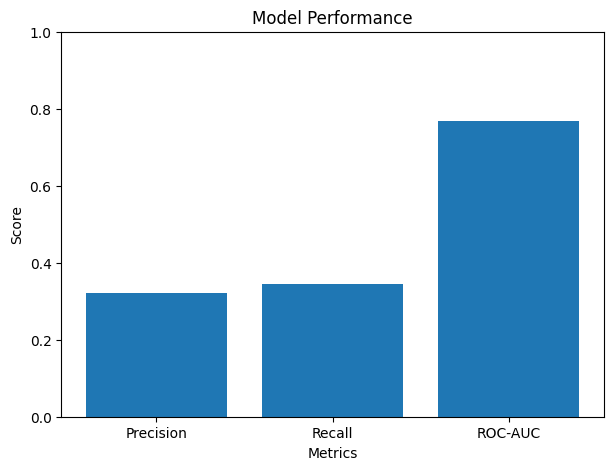

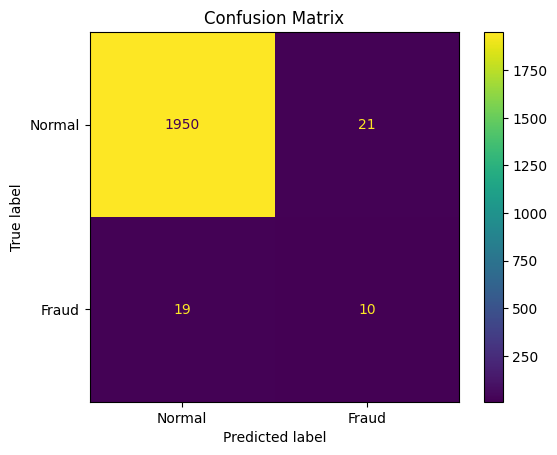

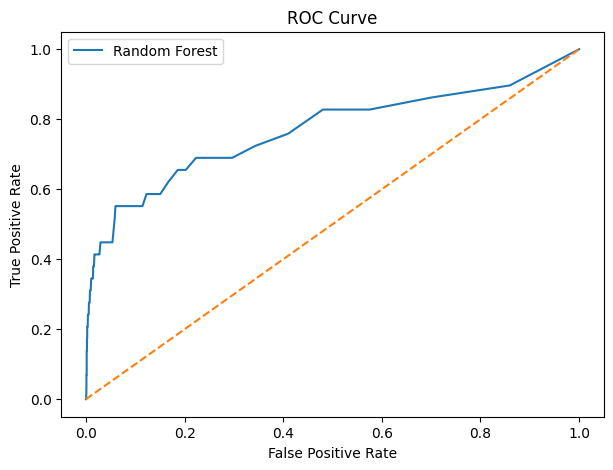

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

X, y = make_classification(
    n_samples=10000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    weights=[0.99, 0.01],
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nFirst 20 Predictions:")
print(y_pred[:20])

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.bar(["Precision", "Recall", "ROC-AUC"], [precision, recall, roc_auc])
plt.ylim(0, 1)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Performance")
plt.show()

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()